In [2]:
!nvidia-smi

Tue May  5 22:13:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.45.03              Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0 Off |                  N/A |
|  0%   40C    P8             30W /  390W |    2435MiB /  24576MiB |      9%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input, ops
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input

2026-05-05 22:13:55.638369: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 22:13:55.650468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778012035.662348  219263 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778012035.665960  219263 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778012035.675704  219263 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [4]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## Load dataset

In [5]:
def load_paths(filepath):
    lines = []
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    base_dir = os.path.dirname(filepath) + '/HR/' + lines[0]
    seq_count = len(os.listdir(base_dir))

    result = [""] * seq_count * len(lines) * 7
    print(len(result))
    for i, line in enumerate(lines):
        for j in range(seq_count):
            for k in range(7):
                index = i * seq_count * 7 + j * 7 + k
                result[index] = os.path.join(f"{line}/{j}/im{k+1}.png")
    return result

In [6]:
train_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/train.txt')
val_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/test.txt')

452284
54768


In [7]:
def create_sr_dataset(
    root_path: str, 
    relative_paths: list[str], 
    batch_size: int = 32,
    is_training: bool = True,
    shuffle_buffer_size: int = 1000
):
    """
    Creates a lazy tf.data.Dataset for Super Resolution.
    
    Args:
        root_path: The base directory containing 'LR' and 'HR' folders.
        relative_paths: List of filenames/relative paths of the images.
        batch_size: The batch size for the dataset.
        is_training: If True, shuffles the dataset. If False, keeps original order for validation/testing.
        shuffle_buffer_size: The number of elements to maintain in the shuffle buffer.
    """
    paths_ds = tf.data.Dataset.from_tensor_slices(relative_paths)
    
    # Shuffle early in the pipeline if this is a training dataset
    if is_training:
        # Buffer size should ideally be larger than the batch size or the full dataset size
        # if memory permits, to ensure true randomness.
        paths_ds = paths_ds.shuffle(buffer_size=shuffle_buffer_size, reshuffle_each_iteration=True)
    
    def process_path(rel_path):
        # Construct the full paths by joining the root, subfolder, and relative path
        lr_path = tf.strings.join([root_path, 'LR', rel_path], separator=os.sep)
        hr_path = tf.strings.join([root_path, 'HR', rel_path], separator=os.sep)
        
        # Read the raw files (lazy loading)
        lr_img = tf.io.read_file(lr_path)
        hr_img = tf.io.read_file(hr_path)
        
        # Decode the images (adjust channels to 1 if using grayscale)
        lr_img = tf.image.decode_image(lr_img, channels=3, expand_animations=False)
        hr_img = tf.image.decode_image(hr_img, channels=3, expand_animations=False)
        
        # Convert to float32 and normalize to [0, 1] range
        lr_img = tf.cast(lr_img, tf.float32) / 255.0
        hr_img = tf.cast(hr_img, tf.float32) / 255.0
        
        return lr_img, hr_img

    # Use map to lazily load and transform the images automatically
    dataset = paths_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch the dataset
    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    
    # Prefetch data to the GPU/Accelerator to prevent I/O bottlenecks
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

In [8]:

root_dir = "/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/"
random.seed(42)
train_files = random.sample(train_paths, int(len(train_paths) * 1))
val_files = random.sample(val_paths, int(len(val_paths) * 1))

# Training dataset (Shuffled and drops incomplete batches)
train_ds = create_sr_dataset(root_dir, train_files, batch_size=32, is_training=True)
# 
# # Validation dataset (Not shuffled, keeps all data)
val_ds = create_sr_dataset(root_dir, val_files, batch_size=32, is_training=False)

I0000 00:00:1778012038.246524  219263 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21764 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


## Visualization

In [9]:
def visualize_dataset_element(dataset, index, model=None):
    """
    Fetches an element at the given index from the dataset.
    If a model is provided, shows LR, Upscaled (with PSNR), and HR images.
    Otherwise, displays just LR and HR.
    """
    # Unbatch to access by raw element index
    unbatched = dataset.unbatch()
    
    for lr, hr in unbatched.skip(index).take(1):
        lr_np = lr.numpy()
        hr_np = hr.numpy()
        
        if model is not None:
            # Predict requires a batch dimension
            lr_batch = tf.expand_dims(lr, 0)
            pred = model(lr_batch)
            
            # Squeeze batch dimension and clip to valid image range
            pred_img = tf.clip_by_value(pred[0], 0.0, 1.0)
            
            # Calculate PSNR
            psnr = tf.image.psnr(hr, pred_img, max_val=1.0).numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(lr_np)
            axes[0].set_title(f"LR Input\n{lr_np.shape}")
            axes[0].axis('off')
            
            axes[1].imshow(pred_img.numpy())
            axes[1].set_title(f"Upscaled Output\nPSNR: {psnr:.2f} dB")
            axes[1].axis('off')
            
            axes[2].imshow(hr_np)
            axes[2].set_title(f"HR Target\n{hr_np.shape}")
            axes[2].axis('off')
            
        else:
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(lr_np)
            axes[0].set_title(f"LR Input\n{lr_np.shape}")
            axes[0].axis('off')
            
            axes[1].imshow(hr_np)
            axes[1].set_title(f"HR Target\n{hr_np.shape}")
            axes[1].axis('off')
            
        plt.tight_layout()
        plt.show()
        return

In [10]:
def plot_training_history(history):
    """
    Plots the training and validation metrics from a Keras History object.
    
    Args:
        history: The history object returned by model.fit()
    """
    # Extract metrics (excluding validation metrics to avoid duplicates)
    metrics = [k for k in history.history.keys() if not k.startswith('val_')]
    
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 4))
    
    # Ensure axes is iterable if there's only one metric (e.g., just loss)
    if n_metrics == 1:
        axes = [axes]
        
    for i, metric in enumerate(metrics):
        axes[i].plot(history.history[metric], label=f'Train {metric}')
        
        # Plot validation metric if it exists
        val_metric = f'val_{metric}'
        if val_metric in history.history:
            axes[i].plot(history.history[val_metric], label=f'Validation {metric}')
            
        axes[i].set_title(f'{metric.capitalize()} over Epochs')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(metric.capitalize())
        axes[i].legend()
        axes[i].grid(True)
        
    plt.tight_layout()
    plt.show()

## Metrics

In [11]:
def psnr_metric(y_true, y_pred):
    # Calculate PSNR manually to avoid Keras graph-mode Assert issues in tf.image.psnr
    # We add a small epsilon (1e-10) to the MSE to prevent the result from becoming 'inf'
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=[1, 2, 3])
    # PSNR = 10 * log10(max_val^2 / MSE). Here max_val is 1.0.
    # tf.math.log is natural log, so we divide by log(10) to get log10.
    return 10.0 * (tf.math.log(1.0 / (mse + 1e-10)) / tf.math.log(10.0))

def ssmi_metric(y_true, y_pred):
    # Calculate SSIM manually to avoid Keras graph-mode Assert issues in tf.image.ssim
    # We add a small epsilon (1e-10) to prevent the result from becoming NaN
    ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)
    return ssim

def luminance_weighted_loss(weight_y=0.8, weight_uv=0.1):
    if weight_y + 2 * weight_uv != 1.0:
        raise ValueError("Weights must sum to 1.0 (weight_y + 2 * weight_uv = 1.0)")
    def loss(y_true, y_pred):
        # Convert RGB tensors to YUV space
        # Note: tf.image.rgb_to_yuv expects values in the [0, 1] range
        yuv_true = tf.image.rgb_to_yuv(y_true)
        yuv_pred = tf.image.rgb_to_yuv(y_pred)

        # Calculate Mean Squared Error per channel
        # yuv[..., 0] is Y, yuv[..., 1] is U, yuv[..., 2] is V
        mse_y = tf.reduce_mean(tf.square(yuv_true[..., 0] - yuv_pred[..., 0]))
        mse_u = tf.reduce_mean(tf.square(yuv_true[..., 1] - yuv_pred[..., 1]))
        mse_v = tf.reduce_mean(tf.square(yuv_true[..., 2] - yuv_pred[..., 2]))

        # Combine with custom weights
        total_loss = (weight_y * mse_y) + (weight_uv * mse_u) + (weight_uv * mse_v)
        return total_loss
        
    return loss
luminance_loss = luminance_weighted_loss(weight_y=0.8, weight_uv=0.1)

# Create VGG model for perceptual loss
def build_vgg_extractor():
    # Load VGG19 without the dense classification head
    vgg = VGG19(include_top=False, weights='imagenet')
    
    # Freeze the weights so they don't update during ESPCN training
    vgg.trainable = False
    
    # Extract feature maps from an intermediate layer
    extractor = Model(
        inputs=vgg.input, 
        outputs=[vgg.get_layer('block2_conv2').output, vgg.get_layer('block3_conv3').output],
        name="vgg_perceptual_extractor"
    )
    
    # Double-lock trainability for safety
    extractor.trainable = False 
    return extractor
vgg_extractor = build_vgg_extractor()

def perceptual_loss(y_true, y_pred):
    # Scale from [0, 1] up to [0, 255] for VGG preprocessing
    y_true_scaled = y_true * 255.0
    y_pred_scaled = y_pred * 255.0
    
    # Preprocess (center pixel vals and convert RGB -> BGR)
    y_true_vgg = preprocess_input(y_true_scaled)
    y_pred_vgg = preprocess_input(y_pred_scaled)
    
    # Extract features
    f_true, f_true2 = vgg_extractor(y_true_vgg)
    f_pred, f_pred2 = vgg_extractor(y_pred_vgg)
    
    # MSE of features
    return tf.reduce_mean(tf.square(f_true - f_pred)) + tf.reduce_mean(tf.square(f_true2 - f_pred2))

# Calculate the ratio between the luminance loss and the perceptual loss
bilinear_luminance_loss = 0.0009
bilinear_perceptual_loss = 42797.8711
perceptual_ratio = bilinear_luminance_loss / bilinear_perceptual_loss
perceptual_weight = perceptual_ratio * 0.5

def luminance_perceptual_loss(y_true, y_pred):
    # Combine the luminance-weighted loss with the perceptual loss
    return luminance_loss(y_true, y_pred) + perceptual_weight * perceptual_loss(y_true, y_pred)


## Dummy model

In [12]:
def create_dummy_model(x_width, x_height, y_width, y_height, interpolation="lanczos5"):
    inp = tf.keras.layers.Input(shape=(x_height, x_width, 3))
    out = tf.keras.layers.Resizing(y_height, y_width, interpolation=interpolation)(inp)
    model = tf.keras.Model(inputs=inp, outputs=out)
    return model
model_dummy = create_dummy_model(128, 128, 256, 256)

model_dummy.compile(
    optimizer='adam',
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)
model_dummy.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 256, 256, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Keras extensions

In [13]:
# Callbacks that require relative (percentage-based) improvement over the previous best.
class _RelativeImprovementMixin:
    def __init__(self, *args, min_relative_improvement=0.05, **kwargs):
        super().__init__(*args, **kwargs)
        self.min_relative_improvement = float(min_relative_improvement)

    def _is_improvement(self, monitor_value, reference_value):
        # Always accept the first valid monitored value as baseline best.
        if reference_value is None or reference_value in (float("inf"), float("-inf")):
            return True

        # Compute relative change against absolute magnitude of the current best.
        # This works for both positive/negative metrics and avoids divide-by-zero.
        eps = 1e-12
        denom = max(abs(float(reference_value)), eps)

        if self.mode == "min":
            rel_gain = (float(reference_value) - float(monitor_value)) / denom
        else:
            rel_gain = (float(monitor_value) - float(reference_value)) / denom
        #print(f"Relative improvement: {rel_gain:.4f} (current: {monitor_value}, best: {reference_value})")
        return rel_gain >= self.min_relative_improvement


class RelativeModelCheckpoint(_RelativeImprovementMixin, ModelCheckpoint):
    pass


class RelativeReduceLROnPlateau(_RelativeImprovementMixin, ReduceLROnPlateau):
    pass


class RelativeEarlyStopping(_RelativeImprovementMixin, EarlyStopping):
    pass

In [14]:
@tf.keras.utils.register_keras_serializable()
class DepthToSpaceLayer(layers.Layer):
    def __init__(self, scale_factor=2, **kwargs):
        super().__init__(**kwargs)
        self.scale_factor = scale_factor
        
    def call(self, inputs):
        return tf.nn.depth_to_space(inputs, self.scale_factor)
        
    def compute_output_shape(self, input_shape):
        batch, h, w, c = input_shape
        out_h = h * self.scale_factor if h is not None else None
        out_w = w * self.scale_factor if w is not None else None
        out_c = c // (self.scale_factor ** 2) if c is not None else None
        return (batch, out_h, out_w, out_c)
        
    def get_config(self):
        config = super().get_config()
        config.update({"scale_factor": self.scale_factor})
        return config

## Upscaler - Classic CNN

In [15]:

def create_upscaler(input_shape=(None, None, 3), scale_factor=2):
    """
    Creates a very lightweight image upscaling neural network (ESPCN style) 
    optimized for TensorFlow.js and mobile devices.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Feature extraction (happens at low resolution = computationally cheap)
    # Using small number of filters and small kernels
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    
    # Create final channels for depth-to-space (scale_factor^2 * channels)
    channels = input_shape[-1] if len(input_shape) == 3 and input_shape[-1] is not None else 3
    x = layers.Conv2D(channels * (scale_factor ** 2), (3, 3), activation='linear', padding='same')(x)
    
    # Sub-pixel convolution / Spatial Upsampling (zero computation overhead at target resolution)
    outputs = DepthToSpaceLayer(scale_factor=scale_factor)(x)
    
    model = models.Model(
        inputs=inputs, 
        outputs=outputs, 
        name=f'lite_upscaler_{scale_factor}x'
    )
    
    return model

model = create_upscaler(input_shape=(128, 128, 3), scale_factor=2)
model.summary()

Model: "lite_upscaler_2x"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 12)   │         1,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_to_space_layer            │ (None, 256, 256, 3)    │             0 │
│ (DepthToSpaceLayer)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,508 (17.61 KB)

 Trainable params: 4,508 (17.61 KB)

 Non-trainable params: 0 (0.00 B)

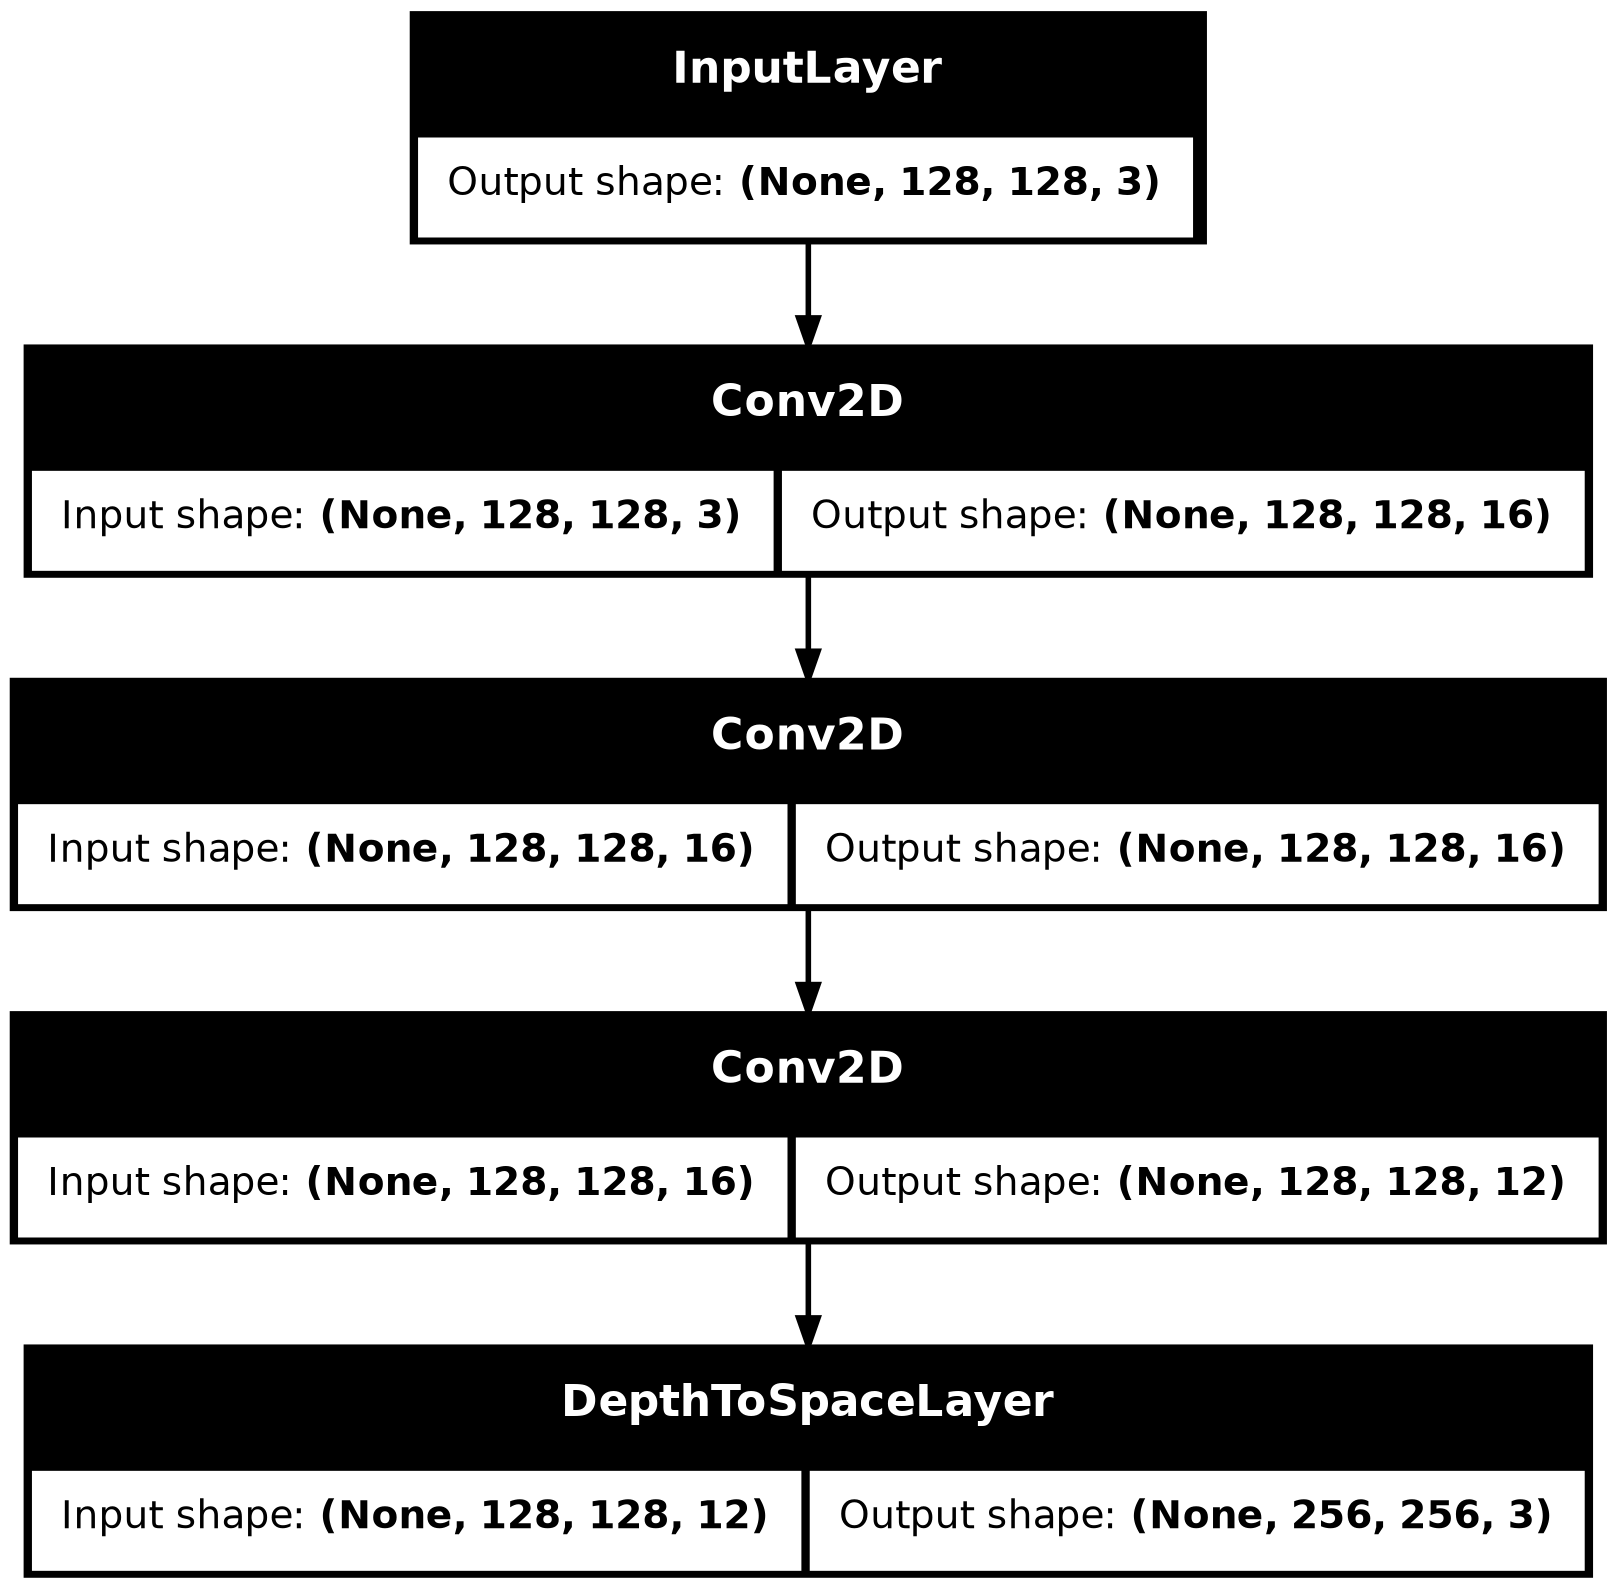

In [16]:
tf.keras.utils.plot_model(
    model,
    to_file='./models/upscale_1_cnn.png',
    show_shapes=True,
    expand_nested=True
)

In [17]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)

# 1. Ensure the checkpoint directory exists
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "upscale_1.keras")

# 2. Define the Callbacks
callbacks = [
    # Save the model whenever validation PSNR improves
    RelativeModelCheckpoint(
        filepath=checkpoint_path,
        monitor="loss", # We monitor our custom metric from compile()
        mode="min",
        min_relative_improvement=0.01, # Only save if val_loss improves by at least 1%
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    # Stop training early if validation loss hasn't improved for a long time
    RelativeEarlyStopping(
        monitor="loss",
        mode="min",
        min_relative_improvement=0.01,
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate if validation loss stops improving
    RelativeReduceLROnPlateau(
        monitor="loss",
        mode="min",
        min_relative_improvement=0.01,
        factor=0.5,       # Halve the learning rate
        patience=3,       # Wait 3 epochs before reducing
        min_lr=1e-10,     # Minimum learning rate lower bound
        verbose=1
    ),
]

print("Starting training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=callbacks
)

Starting training...
Epoch 1/400


I0000 00:00:1778012040.679909  219401 service.cc:152] XLA service 0x7b2b20005090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778012040.679940  219401 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-05-05 22:14:00.794330: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-05 22:14:00.824152: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2026-05-05 22:14:00.824246: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2026-05-05 22:14:00.824532: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2026-05-05 22:14:00.824616: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
I0000

   10/14133 ━━━━━━━━━━━━━━━━━━━━ 4:48 20ms/step - loss: 0.1441 - psnr_metric: 8.1771 - ssmi_metric: 0.0644

I0000 00:00:1778012043.633486  219401 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14132/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0016 - psnr_metric: 30.6289 - ssmi_metric: 0.8512

2026-05-05 22:21:45.342221: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2026-05-05 22:21:45.342513: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2026-05-05 22:21:45.342953: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2026-05-05 22:21:45.343050: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
2026-05-05 22:22:33.679680: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2026-05-05 22:22:33.679727: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2026-05-05 22:22:33.679753: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2026-05-05 22:22:33.679761: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator S


Epoch 1: loss improved from None to 0.00071, saving model to ./checkpoints/upscale_1.keras

Epoch 1: finished saving model to ./checkpoints/upscale_1.keras
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 516s 36ms/step - loss: 7.0547e-04 - psnr_metric: 31.9646 - ssmi_metric: 0.8818 - val_loss: 6.4352e-04 - val_psnr_metric: 31.8602 - val_ssmi_metric: 0.8818 - learning_rate: 0.0010
Epoch 2/400
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 5.3117e-04 - psnr_metric: 32.7489 - ssmi_metric: 0.8942
Epoch 2: loss improved from 0.00071 to 0.00053, saving model to ./checkpoints/upscale_1.keras

Epoch 2: finished saving model to ./checkpoints/upscale_1.keras
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 549s 39ms/step - loss: 5.2881e-04 - psnr_metric: 32.7923 - ssmi_metric: 0.8948 - val_loss: 6.3703e-04 - val_psnr_metric: 31.8756 - val_ssmi_metric: 0.8840 - learning_rate: 0.0010
Epoch 3/400
14132/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 5.2459e-04 - psnr_metric: 32.8669 - ssmi_metric: 0.8956
Epoch 3: loss im

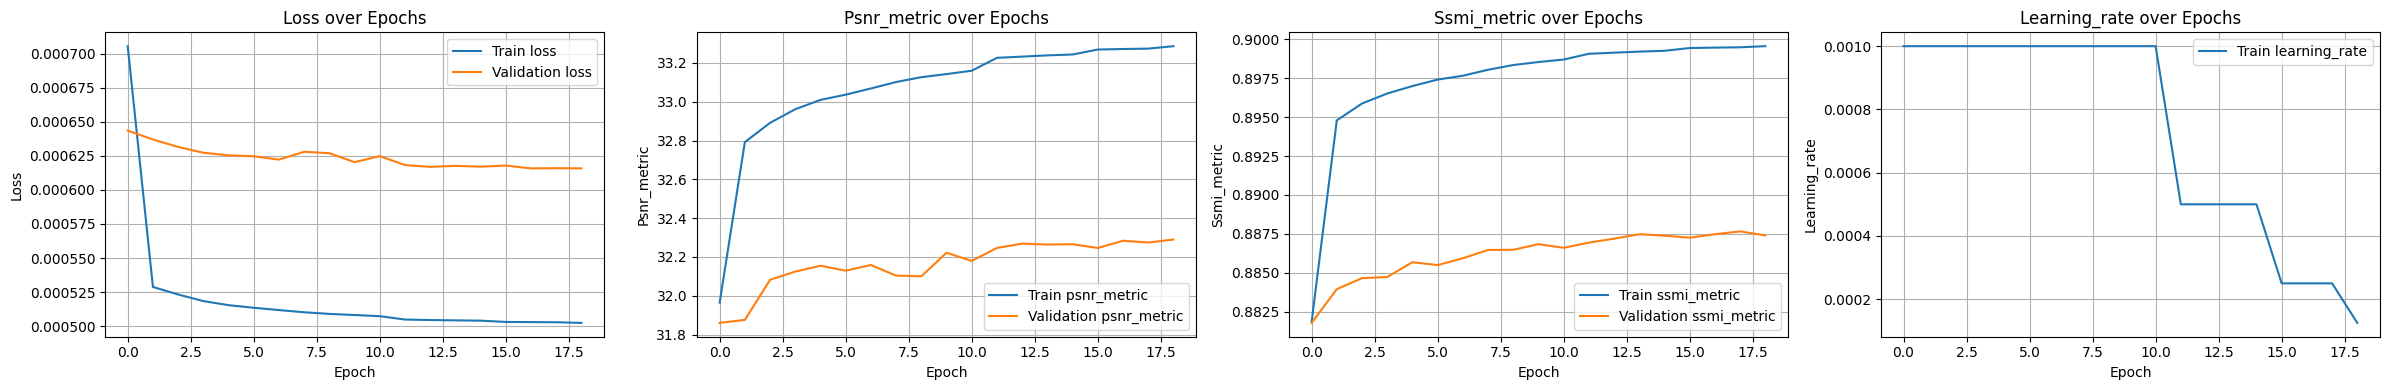

In [18]:
plot_training_history(history)

In [19]:
model.save("./models/upscale_1_cnn.keras")

In [43]:
model = tf.keras.models.load_model(
    './models/upscale_1_cnn.keras',
    custom_objects={
        'loss': luminance_loss,
        'psnr_metric': psnr_metric,
        'ssmi_metric': ssmi_metric
    }
)


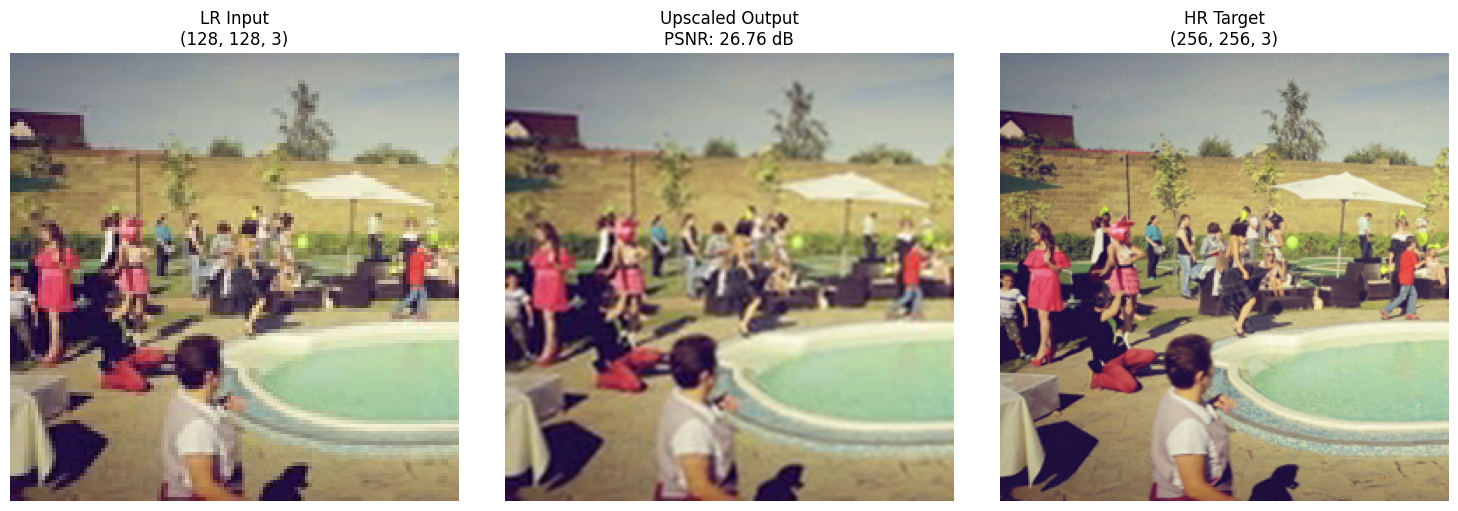

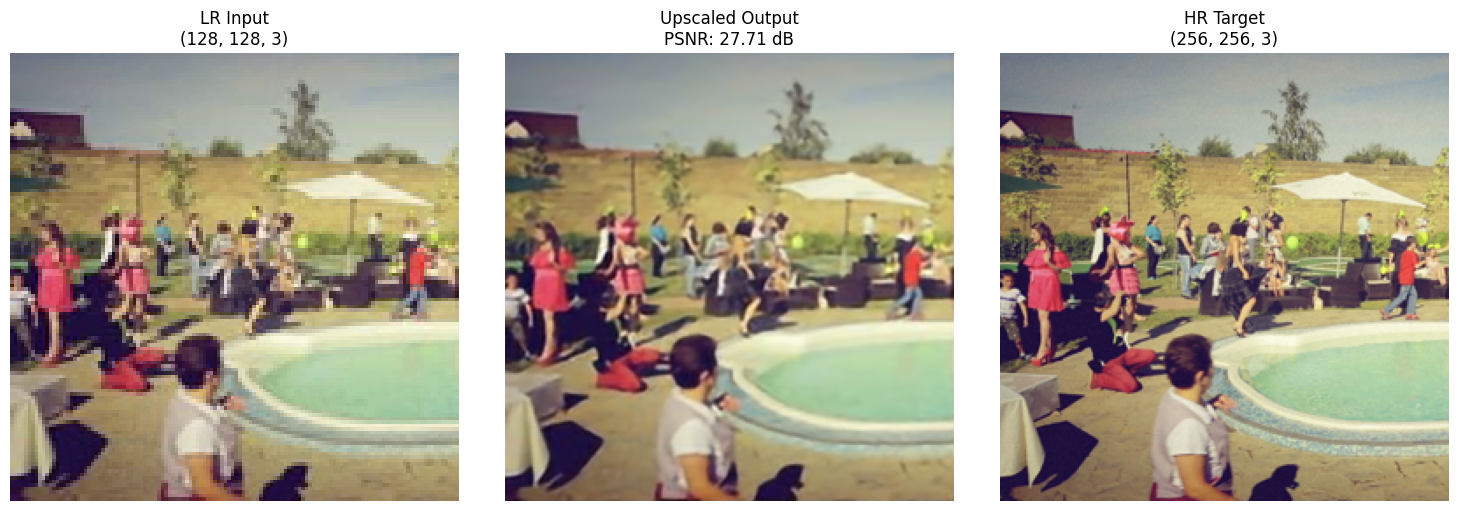

In [49]:
index = 10
visualize_dataset_element(val_ds, index=index, model=model_dummy)
visualize_dataset_element(val_ds, index=index, model=model)

## Perceptual loss

In [22]:
model = create_upscaler(input_shape=(128, 128, 3), scale_factor=2)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1
)

2026-05-06 00:43:28.020619: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2026-05-06 00:43:28.020842: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2026-05-06 00:43:28.021194: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2026-05-06 00:43:28.021245: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert


  889/14133 ━━━━━━━━━━━━━━━━━━━━ 6:09 28ms/step - loss: 0.0121 - psnr_metric: 23.4932 - ssmi_metric: 0.6275

14132/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0018 - psnr_metric: 30.3613 - ssmi_metric: 0.8429

2026-05-06 00:50:04.272015: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2026-05-06 00:50:04.272312: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2026-05-06 00:50:04.272618: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2026-05-06 00:50:04.272690: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert


14133/14133 ━━━━━━━━━━━━━━━━━━━━ 445s 31ms/step - loss: 7.3901e-04 - psnr_metric: 31.8100 - ssmi_metric: 0.8779 - val_loss: 6.5743e-04 - val_psnr_metric: 31.7172 - val_ssmi_metric: 0.8803


In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=luminance_perceptual_loss,
    metrics=[psnr_metric, ssmi_metric]
)

# 1. Ensure the checkpoint directory exists
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_sr_model.keras")

# 2. Define the Callbacks
callbacks = [
    # Save the model whenever validation PSNR improves
    RelativeModelCheckpoint(
        filepath=checkpoint_path,
        monitor="loss", # We monitor our custom metric from compile()
        mode="min",
        min_relative_improvement=0.01, # Only save if val_loss improves by at least 1%
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    # Stop training early if validation loss hasn't improved for a long time
    RelativeEarlyStopping(
        monitor="loss",
        mode="min",
        min_relative_improvement=0.01,
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate if validation loss stops improving
    RelativeReduceLROnPlateau(
        monitor="loss",
        mode="min",
        min_relative_improvement=0.01,
        factor=0.5,       # Halve the learning rate
        patience=3,       # Wait 3 epochs before reducing
        min_lr=1e-10,     # Minimum learning rate lower bound
        verbose=1
    ),
]

print("Starting training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=callbacks
)

Starting training...
Epoch 1/400
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 8.4164e-04 - psnr_metric: 32.4994 - ssmi_metric: 0.8822
Epoch 1: loss improved from None to 0.00084, saving model to ./checkpoints/best_sr_model.keras

Epoch 1: finished saving model to ./checkpoints/best_sr_model.keras
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 1707s 120ms/step - loss: 8.3746e-04 - psnr_metric: 32.5084 - ssmi_metric: 0.8822 - val_loss: 9.9550e-04 - val_psnr_metric: 31.6285 - val_ssmi_metric: 0.8718 - learning_rate: 1.0000e-04
Epoch 2/400
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 8.3155e-04 - psnr_metric: 32.5476 - ssmi_metric: 0.8824
Epoch 2: loss did not improve from 0.00084
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 1661s 117ms/step - loss: 8.2959e-04 - psnr_metric: 32.5650 - ssmi_metric: 0.8829 - val_loss: 9.8764e-04 - val_psnr_metric: 31.6761 - val_ssmi_metric: 0.8735 - learning_rate: 1.0000e-04
Epoch 3/400
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 8.2339e-04 - psnr_metri

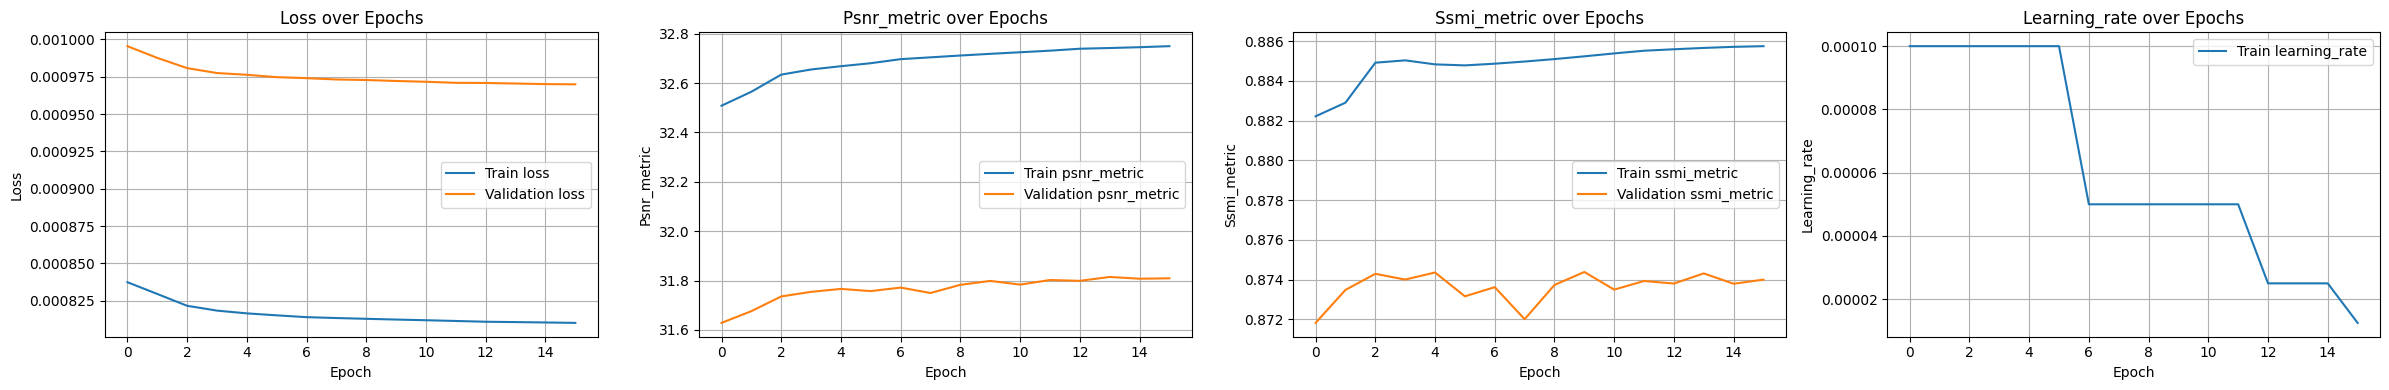

In [25]:
plot_training_history(history)

In [26]:
model.save('./models/upscale_1_cnn_perceptual.keras')

In [50]:
model = tf.keras.models.load_model(
    './models/upscale_1_cnn_perceptual.keras',
    custom_objects={
        'luminance_perceptual_loss': luminance_perceptual_loss,
        'psnr_metric': psnr_metric,
        'ssmi_metric': ssmi_metric
    }
)

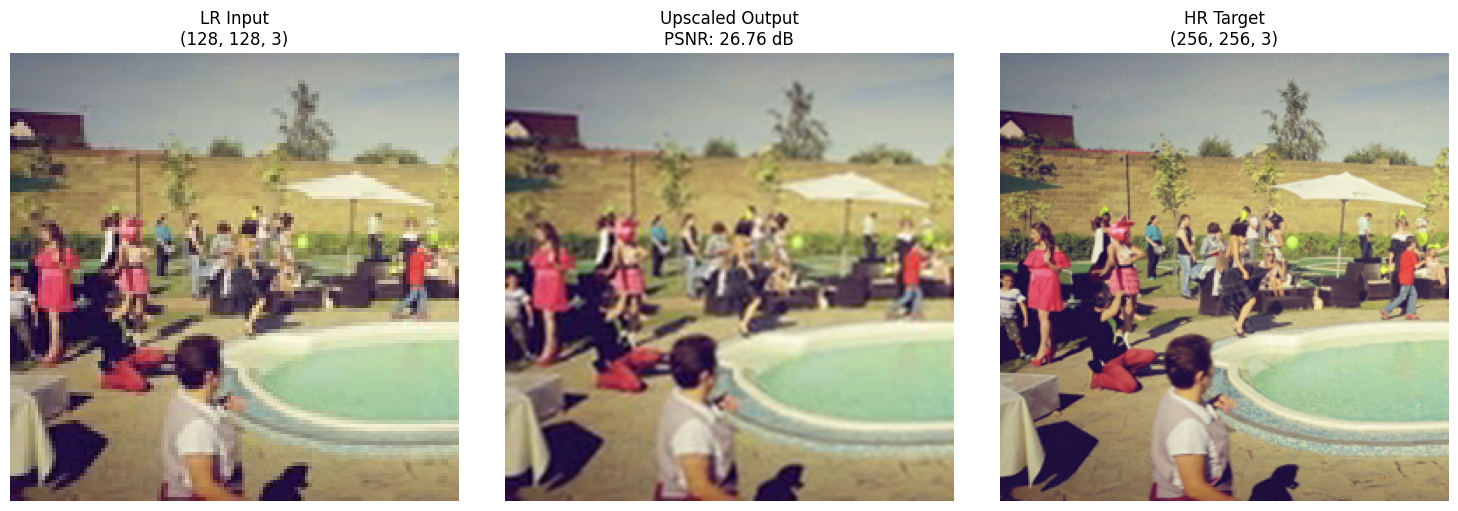

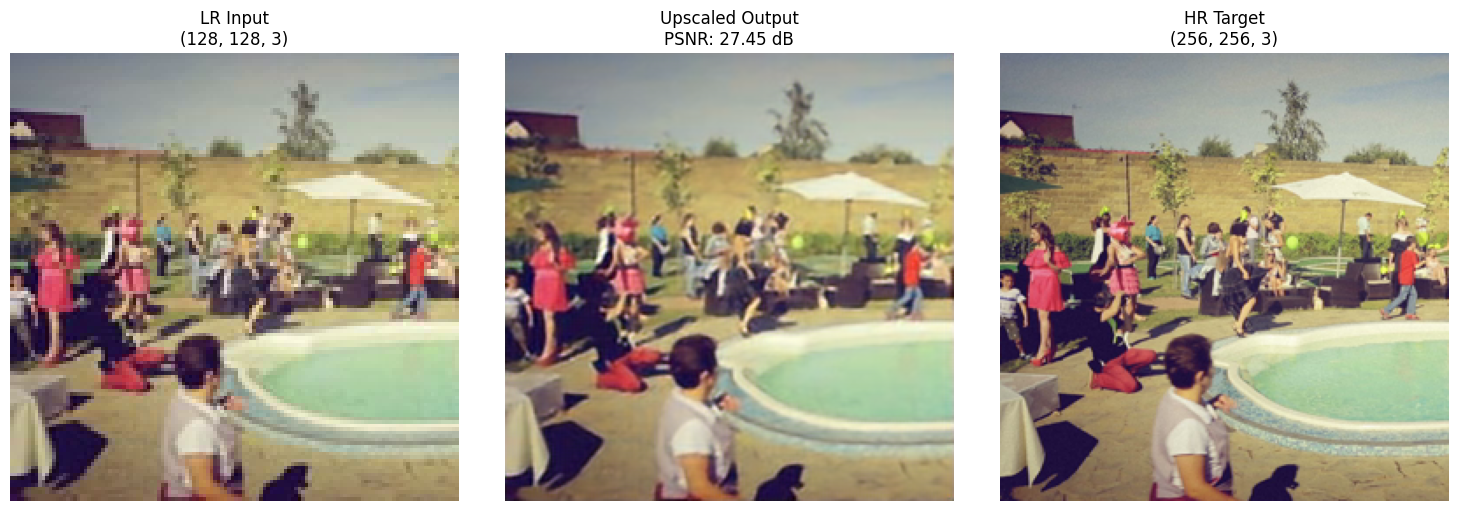

In [51]:
index = 10
visualize_dataset_element(val_ds, index=index, model=model_dummy)
visualize_dataset_element(val_ds, index=index, model=model)

## Upscale - Residual CNN

In [29]:
def create_upscaler_resnet(input_shape=(None, None, 3), scale_factor=2):
    """
    Creates a very lightweight image upscaling neural network (ESPCN style) 
    optimized for TensorFlow.js and mobile devices.
    """
    inputs = layers.Input(shape=input_shape)
    y = layers.Resizing(input_shape[0] * scale_factor, input_shape[1] * scale_factor, interpolation='bilinear')(inputs)
    
    # Feature extraction (happens at low resolution = computationally cheap)
    # Using small number of filters and small kernels
    x = layers.Conv2D(12, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(3, (3, 3), activation='relu', padding='same')(x)

    x = layers.Add()([x, inputs])  # Skip connection at low resolution
    z = x
    x = layers.Conv2D(12, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(3, (3, 3), activation='relu', padding='same')(x)
    x = layers.Add()([x, z])  # Skip connection before upscaling

    # Create final channels for depth-to-space (scale_factor^2 * channels)
    channels = input_shape[-1] if len(input_shape) == 3 and input_shape[-1] is not None else 3
    x = layers.Conv2D(channels * (scale_factor ** 2), (3, 3), activation='sigmoid', padding='same')(x)
    
    # Sub-pixel convolution / Spatial Upsampling (zero computation overhead at target resolution)
    x = DepthToSpaceLayer(scale_factor=scale_factor)(x)
    
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(12, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    # Scale down the skip connection to prevent overpowering (works with any shape)
    y = layers.Lambda(lambda x: x * 0.5)(y)
    x = layers.Add()([x, y])  # Final skip connection after upscaling

    outputs = x
    
    model = models.Model(
        inputs=inputs, 
        outputs=outputs, 
        name=f'lite_upscaler_{scale_factor}x'
    )
    
    return model

model = create_upscaler_resnet(input_shape=(128, 128, 3), scale_factor=2)
model.summary()

Model: "lite_upscaler_2x"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │        336 │ input_layer_4[0]… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │        327 │ conv2d_6[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ conv2d_7[0][0],   │
│                     │ 3)                │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │        336 │ add[0][0]         │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │        327 │ conv2d_8[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ conv2d_9[0][0],   │
│                     │ 3)                │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 128, 128,  │        336 │ add_1[0][0]       │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_to_space_lay… │ (None, 256, 256,  │          0 │ conv2d_10[0][0]   │
│ (DepthToSpaceLayer) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │        448 │ depth_to_space_l… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │      1,740 │ conv2d_11[0][0]   │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 256, 256,  │          0 │ input_layer_4[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 256, 256,  │        327 │ conv2d_12[0][0]   │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256, 256,  │          0 │ resizing_1[0][0]  │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 256,  │          0 │ conv2d_13[0][0],  │
│                     │ 3)                │            │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,177 (16.32 KB)

 Trainable params: 4,177 (16.32 KB)

 Non-trainable params: 0 (0.00 B)

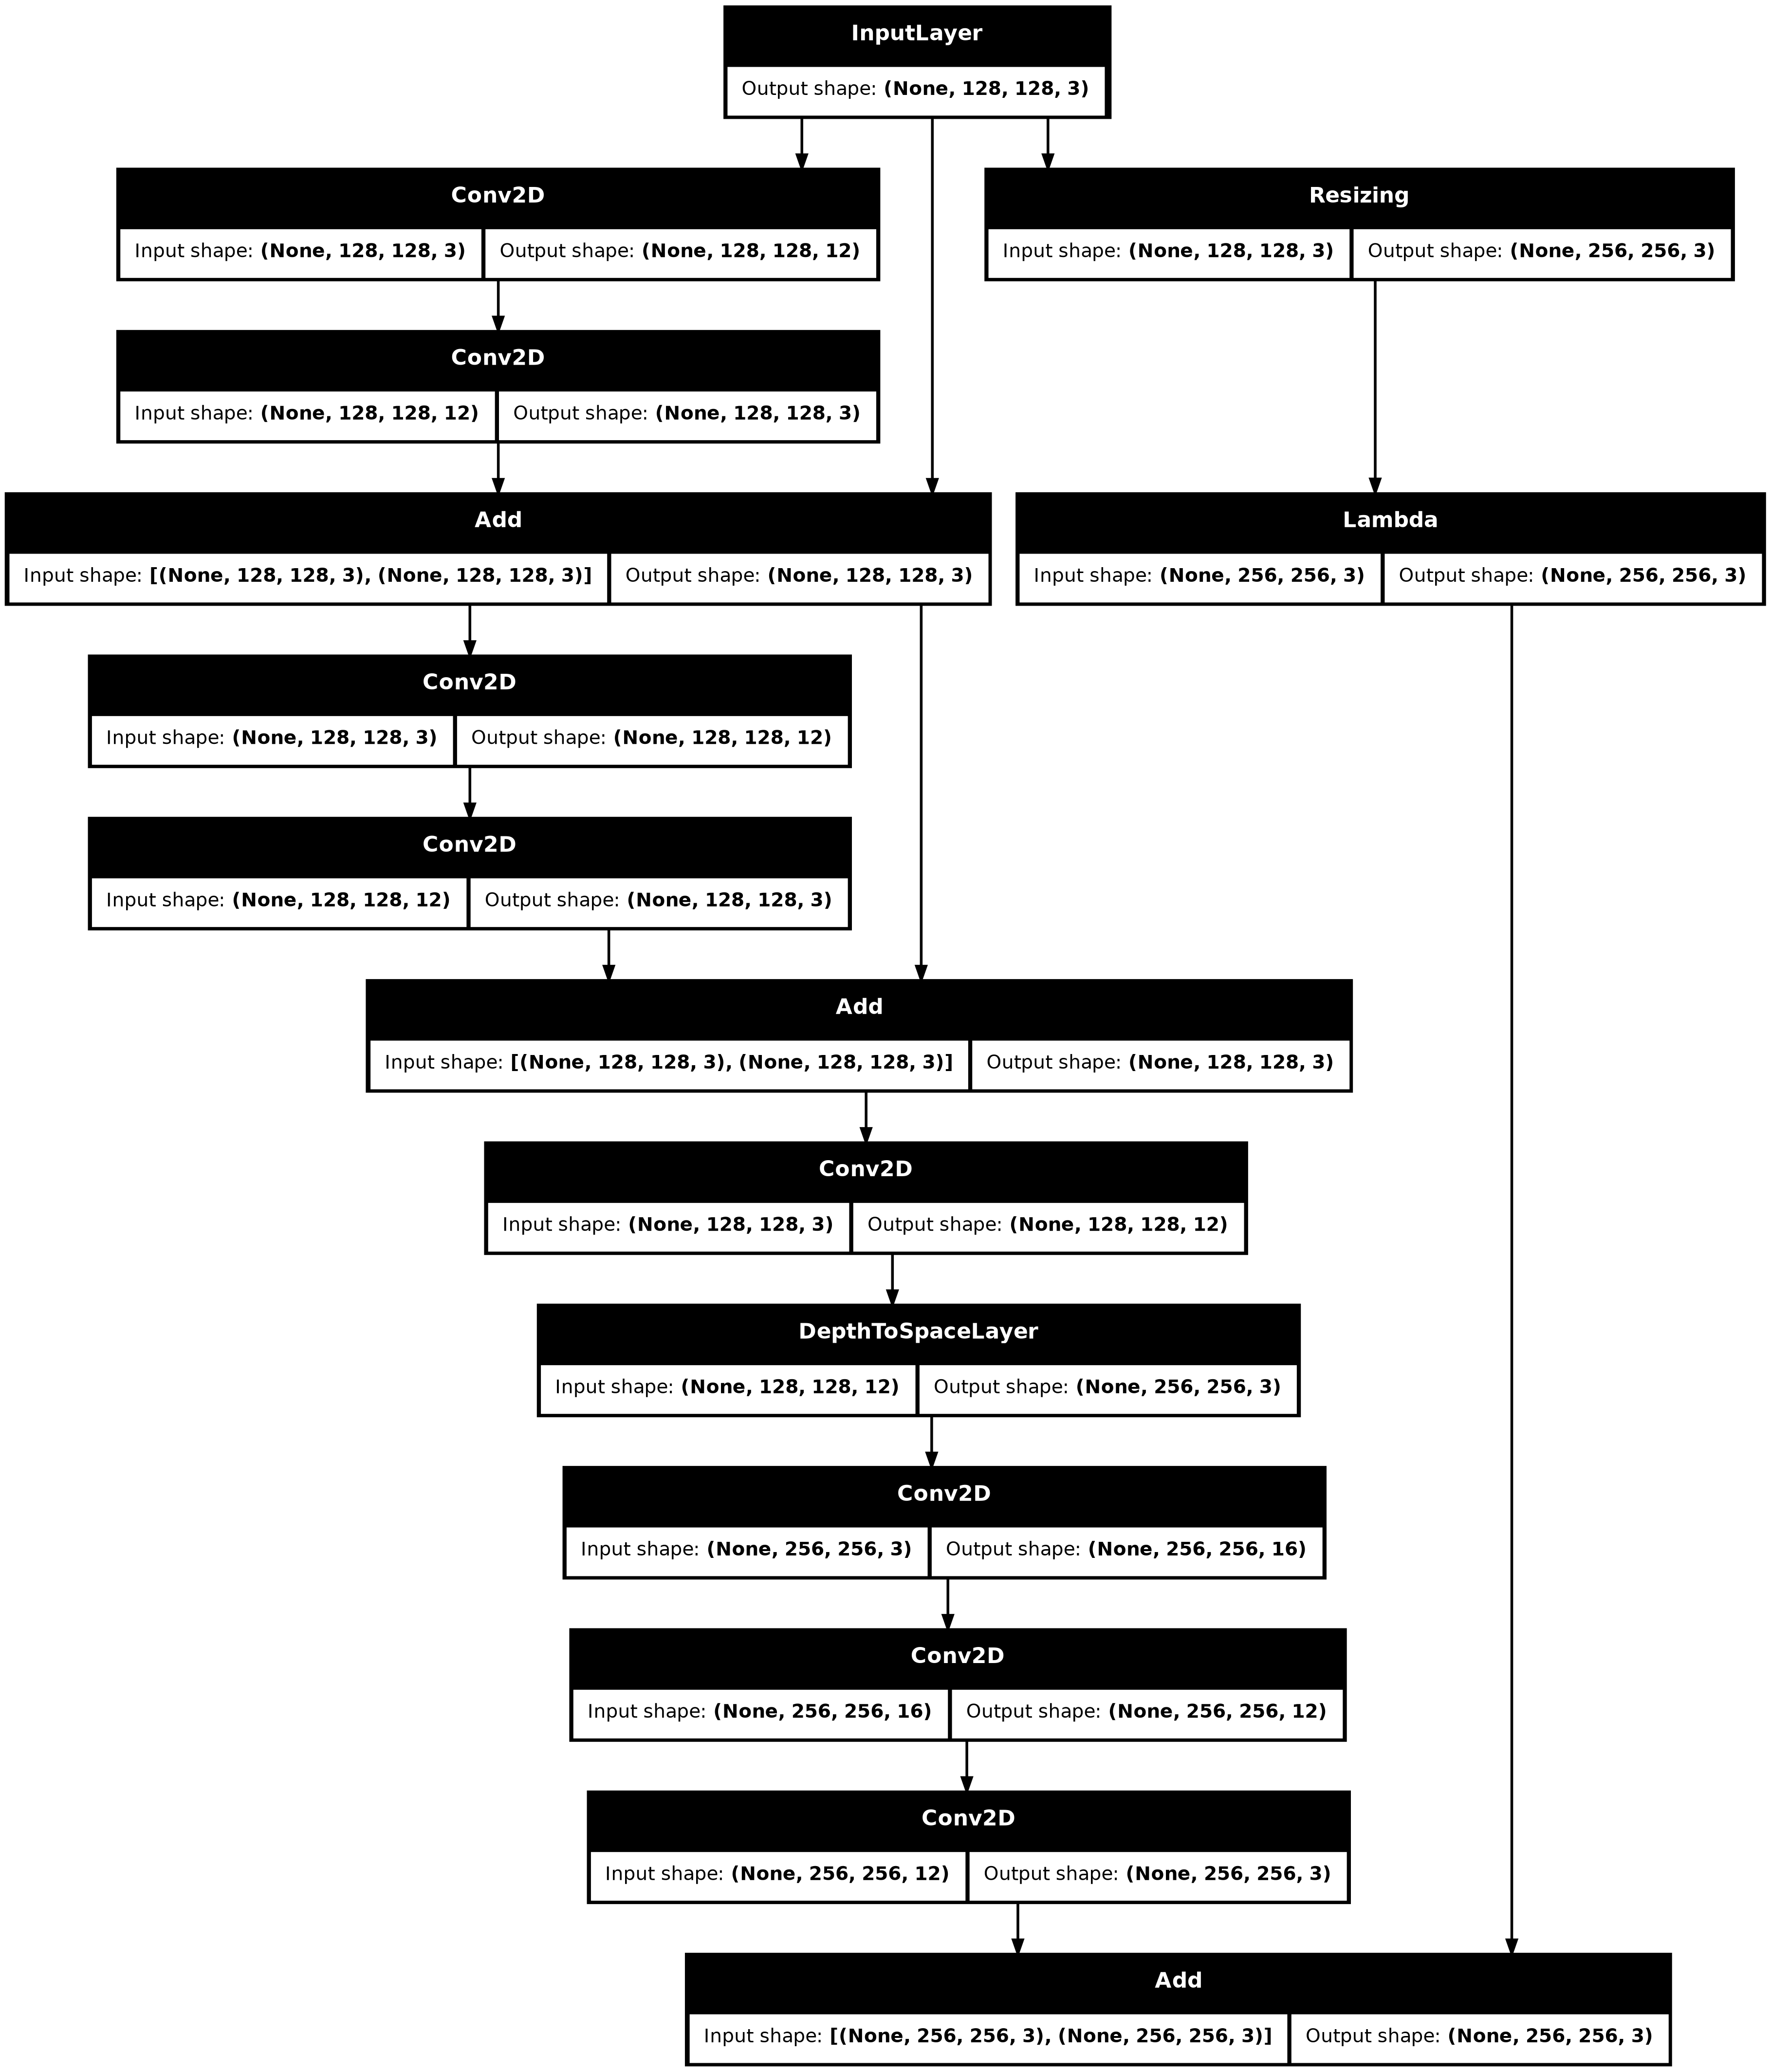

In [30]:
tf.keras.utils.plot_model(
    model,
    to_file='./models/upscale_1_resnet.png',
    show_shapes=True,
    expand_nested=True
)

In [31]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)

# 1. Ensure the checkpoint directory exists
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_sr_model.keras")

# 2. Define the Callbacks
callbacks = [
    # Save the model whenever validation PSNR improves
    RelativeModelCheckpoint(
        filepath=checkpoint_path,
        monitor="loss", # We monitor our custom metric from compile()
        mode="min",
        min_relative_improvement=0.005, # Only save if val_loss improves by at least 0.5%
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    # Stop training early if validation loss hasn't improved for a long time
    RelativeEarlyStopping(
        monitor="loss",
        mode="min",
        min_relative_improvement=0.005,
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate if validation loss stops improving
    RelativeReduceLROnPlateau(
        monitor="loss",
        mode="min",
        min_relative_improvement=0.005,
        factor=0.5,       # Halve the learning rate
        patience=3,       # Wait 3 epochs before reducing
        min_lr=1e-10,     # Minimum learning rate lower bound
        verbose=1
    ),
]



print("Starting training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=callbacks
)

Starting training...
Epoch 1/400
14132/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0019 - psnr_metric: 30.3019 - ssmi_metric: 0.8722
Epoch 1: loss improved from None to 0.00075, saving model to ./checkpoints/best_sr_model.keras

Epoch 1: finished saving model to ./checkpoints/best_sr_model.keras
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 664s 46ms/step - loss: 7.5233e-04 - psnr_metric: 31.6371 - ssmi_metric: 0.8876 - val_loss: 6.4610e-04 - val_psnr_metric: 31.7104 - val_ssmi_metric: 0.8816 - learning_rate: 0.0010
Epoch 2/400
14132/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 5.2617e-04 - psnr_metric: 32.7082 - ssmi_metric: 0.8949
Epoch 2: loss improved from 0.00075 to 0.00052, saving model to ./checkpoints/best_sr_model.keras

Epoch 2: finished saving model to ./checkpoints/best_sr_model.keras
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 616s 44ms/step - loss: 5.2339e-04 - psnr_metric: 32.7592 - ssmi_metric: 0.8955 - val_loss: 6.3131e-04 - val_psnr_metric: 31.9152 - val_ssmi_metric: 0.8844 - learni

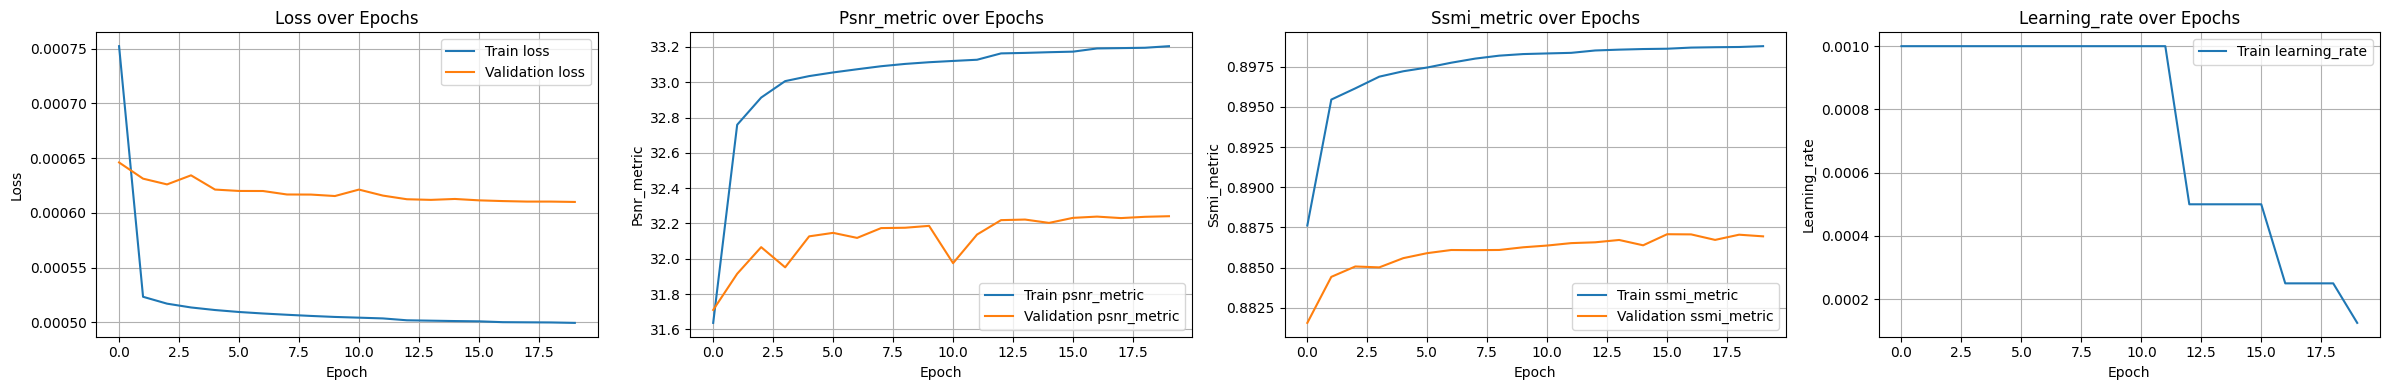

In [32]:
plot_training_history(history)

In [33]:
model.save('./models/upscale_1_resnet.keras')

In [52]:
model = tf.keras.models.load_model(
    './models/upscale_1_resnet.keras',
    custom_objects={
        'loss': luminance_loss,
        'psnr_metric': psnr_metric,
        'ssmi_metric': ssmi_metric
    },
    safe_mode=False
)

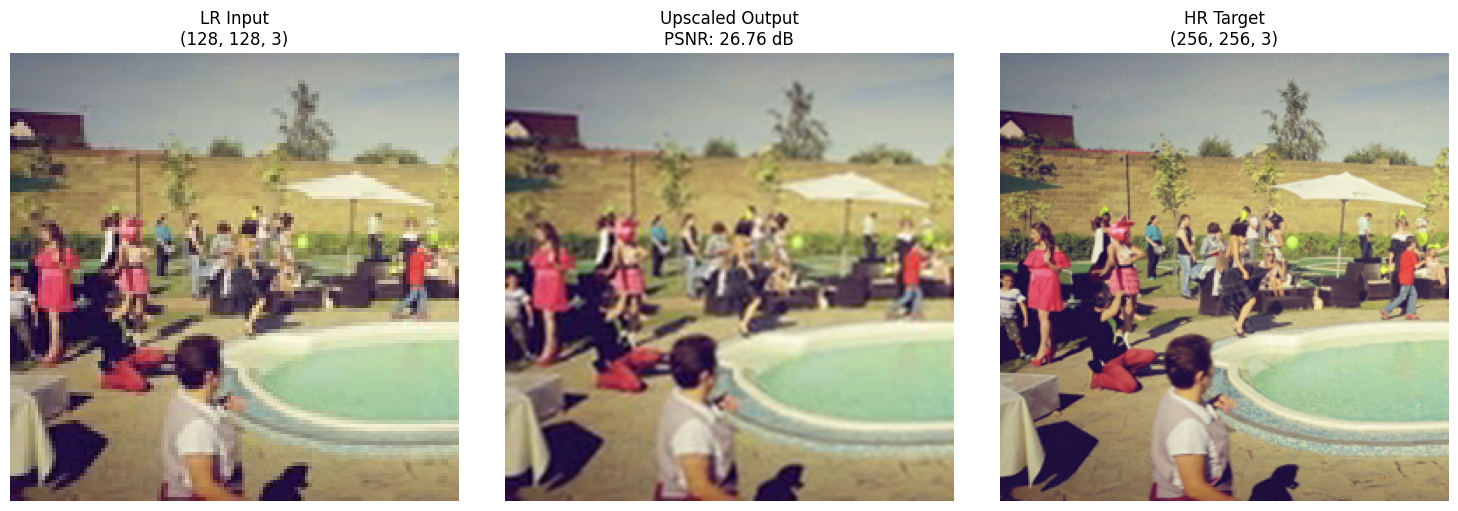

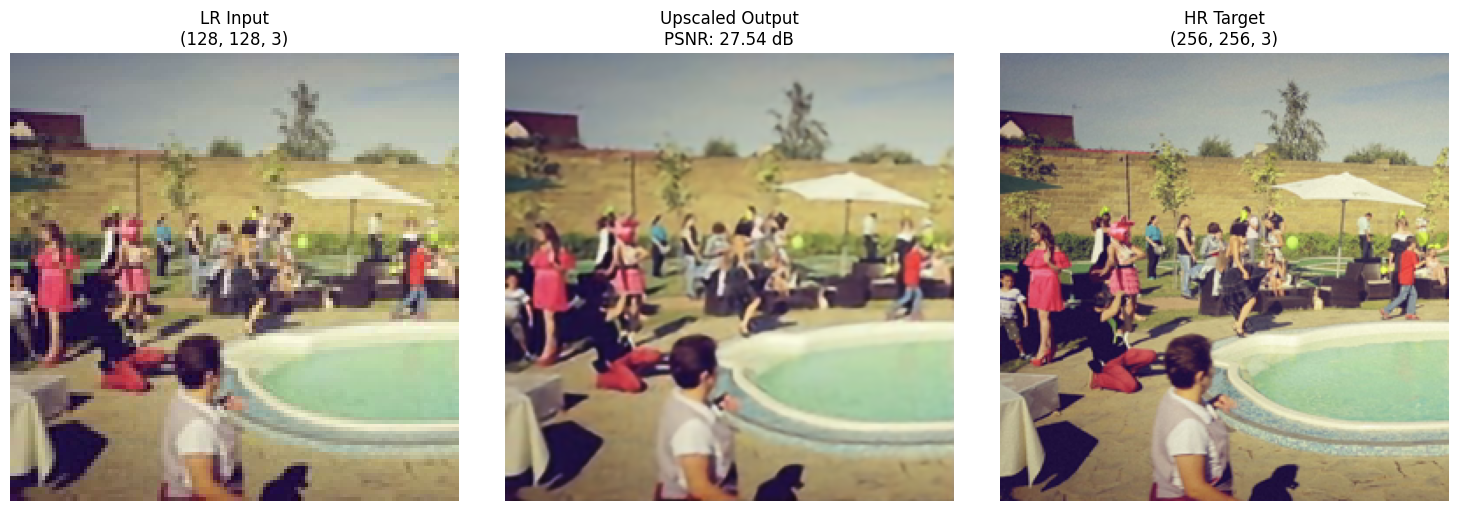

In [54]:
index = 10
visualize_dataset_element(val_ds, index=index, model=model_dummy)
visualize_dataset_element(val_ds, index=index, model=model)

## Perceptual loss

In [36]:
model = create_upscaler(input_shape=(128, 128, 3), scale_factor=2)

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1
)

14133/14133 ━━━━━━━━━━━━━━━━━━━━ 449s 32ms/step - loss: 7.1391e-04 - psnr_metric: 31.5649 - ssmi_metric: 0.8774 - val_loss: 6.6860e-04 - val_psnr_metric: 31.5766 - val_ssmi_metric: 0.8785


In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=luminance_perceptual_loss,
    metrics=[psnr_metric, ssmi_metric]
)

# 1. Ensure the checkpoint directory exists
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_sr_model.keras")

# 2. Define the Callbacks
callbacks = [
    # Save the model whenever validation PSNR improves
    RelativeModelCheckpoint(
        filepath=checkpoint_path,
        monitor="loss", # We monitor our custom metric from compile()
        mode="min",
        min_relative_improvement=0.01, # Only save if val_loss improves by at least 1%
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    # Stop training early if validation loss hasn't improved for a long time
    RelativeEarlyStopping(
        monitor="loss",
        mode="min",
        min_relative_improvement=0.01,
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate if validation loss stops improving
    RelativeReduceLROnPlateau(
        monitor="loss",
        mode="min",
        min_relative_improvement=0.01,
        factor=0.5,       # Halve the learning rate
        patience=3,       # Wait 3 epochs before reducing
        min_lr=1e-10,     # Minimum learning rate lower bound
        verbose=1
    ),
]

print("Starting training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=callbacks
)

Starting training...
Epoch 1/400


14133/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 8.5447e-04 - psnr_metric: 32.4053 - ssmi_metric: 0.8835
Epoch 1: loss improved from None to 0.00085, saving model to ./checkpoints/best_sr_model.keras

Epoch 1: finished saving model to ./checkpoints/best_sr_model.keras
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 1688s 119ms/step - loss: 8.4835e-04 - psnr_metric: 32.4311 - ssmi_metric: 0.8834 - val_loss: 0.0010 - val_psnr_metric: 31.5526 - val_ssmi_metric: 0.8711 - learning_rate: 1.0000e-04
Epoch 2/400
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 8.4011e-04 - psnr_metric: 32.4806 - ssmi_metric: 0.8831
Epoch 2: loss improved from 0.00085 to 0.00084, saving model to ./checkpoints/best_sr_model.keras

Epoch 2: finished saving model to ./checkpoints/best_sr_model.keras
14133/14133 ━━━━━━━━━━━━━━━━━━━━ 1685s 119ms/step - loss: 8.3805e-04 - psnr_metric: 32.4935 - ssmi_metric: 0.8832 - val_loss: 9.9881e-04 - val_psnr_metric: 31.6185 - val_ssmi_metric: 0.8721 - learning_rate: 1.0000e-04
Epo

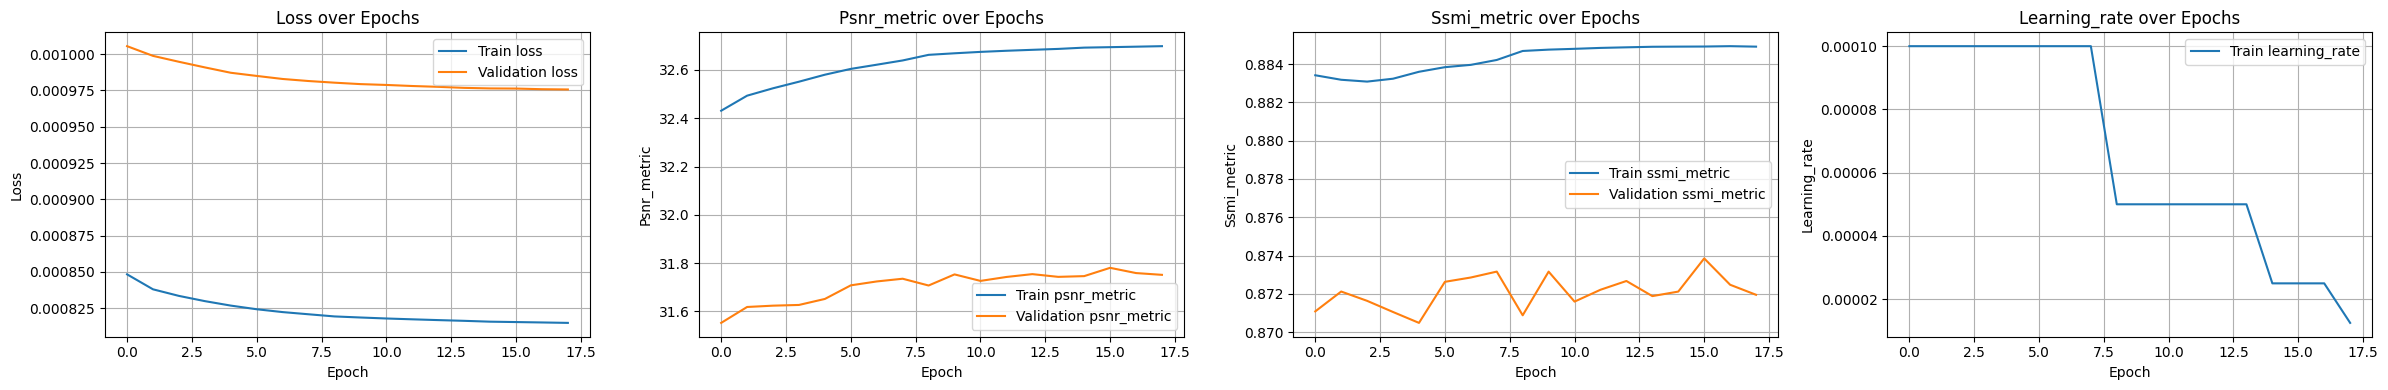

In [39]:
plot_training_history(history)

In [40]:
model.save('./models/upscale_1_resnet_perceptual.keras')

In [55]:
model = tf.keras.models.load_model(
    './models/upscale_1_resnet_perceptual.keras',
    custom_objects={
        'luminance_perceptual_loss': luminance_perceptual_loss,
        'psnr_metric': psnr_metric,
        'ssmi_metric': ssmi_metric
    },
    safe_mode=False
)

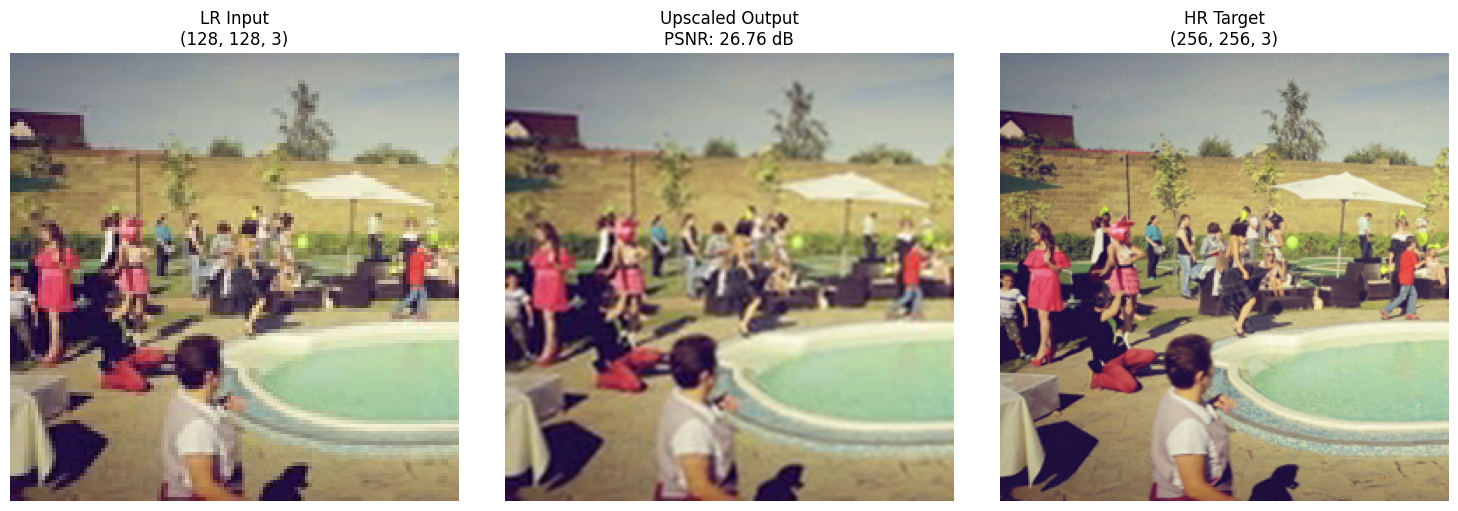

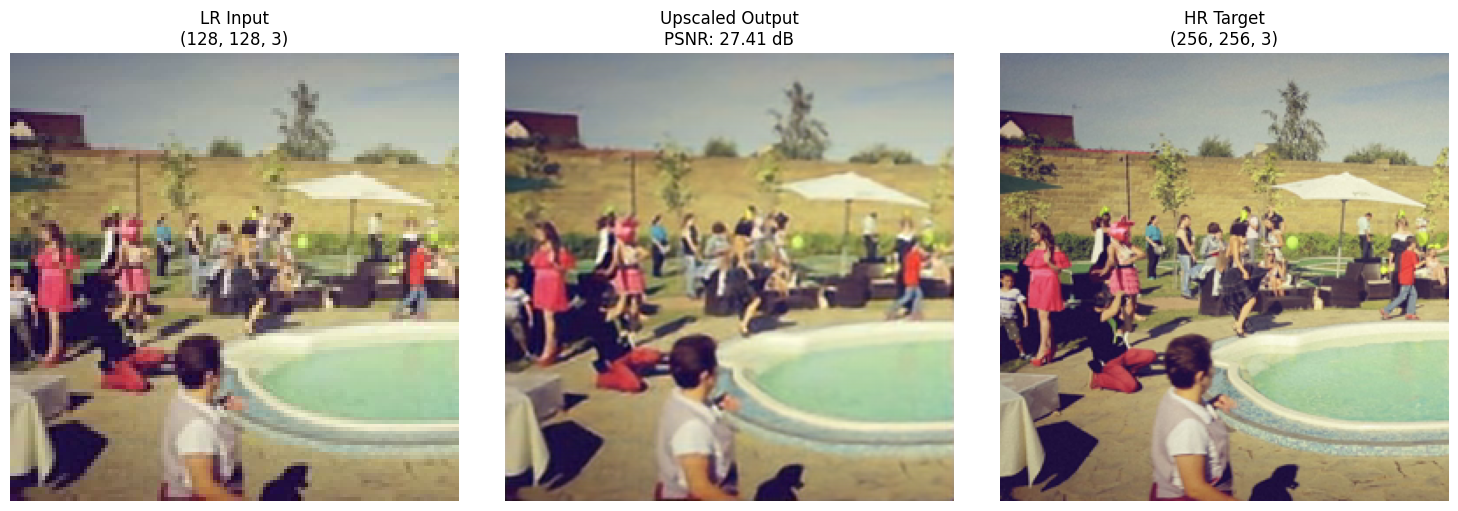

In [56]:
index = 10
visualize_dataset_element(val_ds, index=index, model=model_dummy)
visualize_dataset_element(val_ds, index=index, model=model)